In [2]:
import pandas as pd

# Load e-commerce data
ec_df = pd.read_csv("Kaggle-Womens Clothing E-Commerce Reviews.csv")

# Load Reddit data
reddit_df = pd.read_csv("reddit_comments.csv")

# Check basic info
print("=== E-Commerce Data ===")
print(ec_df.shape)
print(ec_df.columns.tolist())
print(ec_df.head(3))

print("\n=== Reddit Data ===")
print(reddit_df.shape)
print(reddit_df.columns.tolist())
print(reddit_df.head(3))

=== E-Commerce Data ===
(23486, 11)
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   

   Positive Feedback Count Division Name Department Name Class Name  
0                        0     Initmates        Intimate  Intimates  
1                        4       General         Dresses    Dresses  
2                    

In [3]:
# Drop unnecessary column
ec_df = ec_df.drop(columns=["Unnamed: 0"])

# Check missing values
print("=== Missing Values: E-Commerce ===")
print(ec_df.isnull().sum())

print("\n=== Missing Values: Reddit ===")
print(reddit_df.isnull().sum())

=== Missing Values: E-Commerce ===
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

=== Missing Values: Reddit ===
subreddit         0
search_query      0
post_title        0
post_id           0
comment           0
comment_score     0
post_url          0
comment_length    0
dtype: int64


In [4]:
# Drop rows where Review Text is missing (core analysis column)
ec_df = ec_df.dropna(subset=["Review Text"])

# Drop rows where Division/Department/Class Name is missing
ec_df = ec_df.dropna(subset=["Division Name", "Department Name", "Class Name"])

# Confirm result
print(f"E-Commerce data after cleaning: {ec_df.shape}")
print(f"Missing values remaining:\n{ec_df.isnull().sum()}")

E-Commerce data after cleaning: (22628, 10)
Missing values remaining:
Clothing ID                   0
Age                           0
Title                      2966
Review Text                   0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                 0
Department Name               0
Class Name                    0
dtype: int64


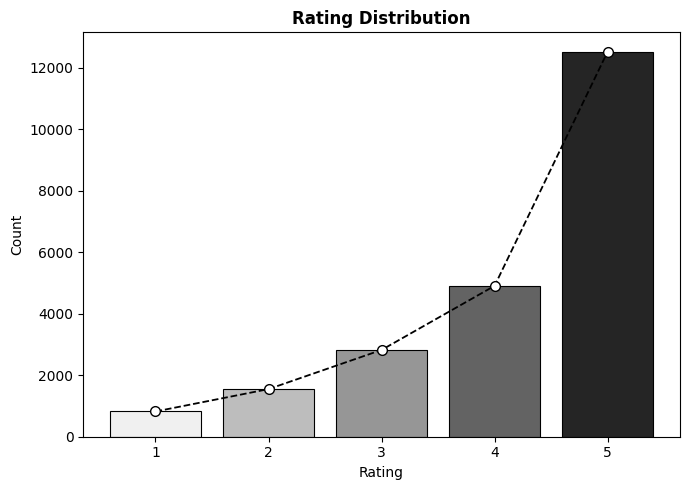

=== Rating Overview ===
Average Rating: 4.18
Median Rating: 5.0
Mode Rating: 5
=== Rating Counts ===
Rating
1      821
2     1549
3     2823
4     4908
5    12527
Name: count, dtype: int64

=== Recommendation Counts ===
Recommended IND
1    18527
0     4101
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt

# Rating distribution (single plot, greyscale + trend line)
fig, ax = plt.subplots(figsize=(7, 5))

rating_counts = ec_df["Rating"].value_counts().sort_index()
grey_shades = ["#f0f0f0", "#bdbdbd", "#969696", "#636363", "#252525"]

ax.bar(rating_counts.index, rating_counts.values,
       color=grey_shades, edgecolor="black", linewidth=0.8)
ax.plot(rating_counts.index, rating_counts.values,
        color="black", marker="o", linestyle="--", linewidth=1.3,
        markersize=7, markerfacecolor="white", markeredgecolor="black")
ax.set_title("Rating Distribution",fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("rating_distribution_bw.png", dpi=300)
plt.show()

# Print exact numbers
print("=== Rating Overview ===")
print(f"Average Rating: {ec_df['Rating'].mean().round(2)}")
print(f"Median Rating: {ec_df['Rating'].median()}")
print(f"Mode Rating: {ec_df['Rating'].mode()[0]}")

print("=== Rating Counts ===")
print(ec_df["Rating"].value_counts().sort_index())

print("\n=== Recommendation Counts ===")
print(ec_df["Recommended IND"].value_counts())

In [6]:
from scipy.stats import chi2_contingency
import pandas as pd

contingency = pd.crosstab(ec_df["Rating"], ec_df["Recommended IND"])
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
cramers_v = (chi2 / (contingency.values.sum() * (min(contingency.shape) - 1))) ** 0.5

print(f"\nChi2 = {chi2:.2f}, df = {dof}, p = {p:.4e}")
print(f"Cramer's V = {cramers_v:.3f}")

Recommended IND     0      1
Rating                      
1                 806     15
2                1455     94
3                1653   1170
4                 164   4744
5                  23  12504

Chi2 = 16093.90, df = 4, p = 0.0000e+00
Cramer's V = 0.843


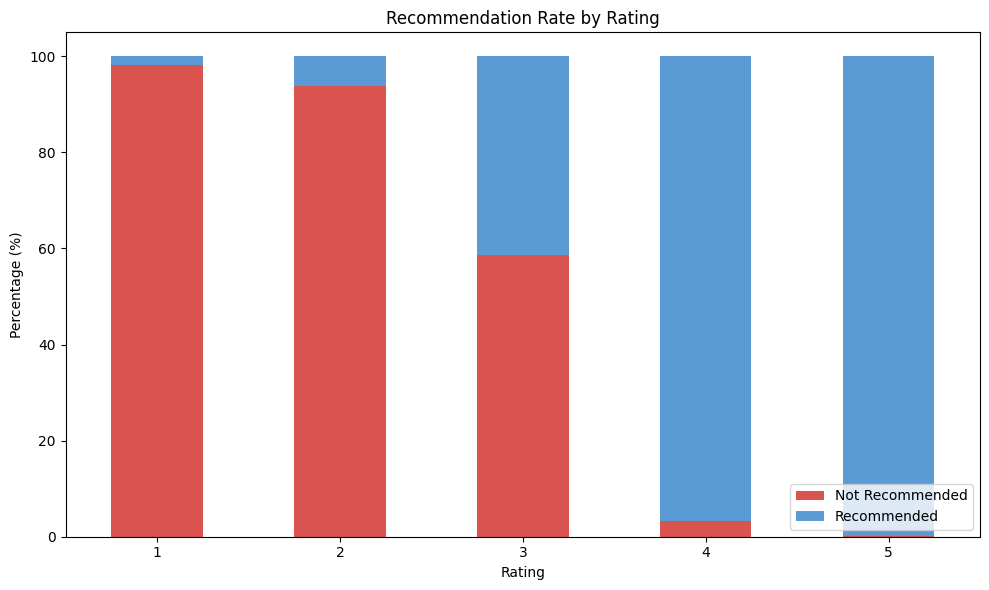

=== Recommendation Rate by Rating (%) ===
        Not Recommended  Recommended
Rating                              
1                  98.2          1.8
2                  93.9          6.1
3                  58.6         41.4
4                   3.3         96.7
5                   0.2         99.8

=== Raw Counts ===
Recommended IND     0      1
Rating                      
1                 806     15
2                1455     94
3                1653   1170
4                 164   4744
5                  23  12504


In [7]:
# Calculate recommendation rate by rating
rec_by_rating = ec_df.groupby("Rating")["Recommended IND"].value_counts(normalize=True).unstack()
rec_by_rating.columns = ["Not Recommended", "Recommended"]
rec_by_rating = rec_by_rating * 100  # convert to percentage

# Plot stacked bar chart
rec_by_rating.plot(kind="bar", stacked=True, figsize=(10, 6), 
                   color=["#d9534f", "#5b9bd5"])
plt.title("Recommendation Rate by Rating")
plt.xlabel("Rating")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("recommendation_by_rating.png", dpi=150)
plt.show()

# Print exact numbers
print("=== Recommendation Rate by Rating (%) ===")
print(rec_by_rating.round(1))

# Print raw counts
print("\n=== Raw Counts ===")
print(ec_df.groupby("Rating")["Recommended IND"].value_counts().unstack())

In [8]:
# Extract inconsistent cases
low_rating_recommended = ec_df[(ec_df["Rating"] <= 2) & (ec_df["Recommended IND"] == 1)]
high_rating_not_recommended = ec_df[(ec_df["Rating"] >= 4) & (ec_df["Recommended IND"] == 0)]
rating3 = ec_df[ec_df["Rating"] == 3]

print(f"Low rating (1-2) but recommended: {len(low_rating_recommended)}")
print(f"High rating (4-5) but not recommended: {len(high_rating_not_recommended)}")
print(f"Rating 3 total: {len(rating3)}")
print(f"Rating 3 recommended: {len(rating3[rating3['Recommended IND'] == 1])}")
print(f"Rating 3 not recommended: {len(rating3[rating3['Recommended IND'] == 0])}")

Low rating (1-2) but recommended: 109
High rating (4-5) but not recommended: 187
Rating 3 total: 2823
Rating 3 recommended: 1170
Rating 3 not recommended: 1653


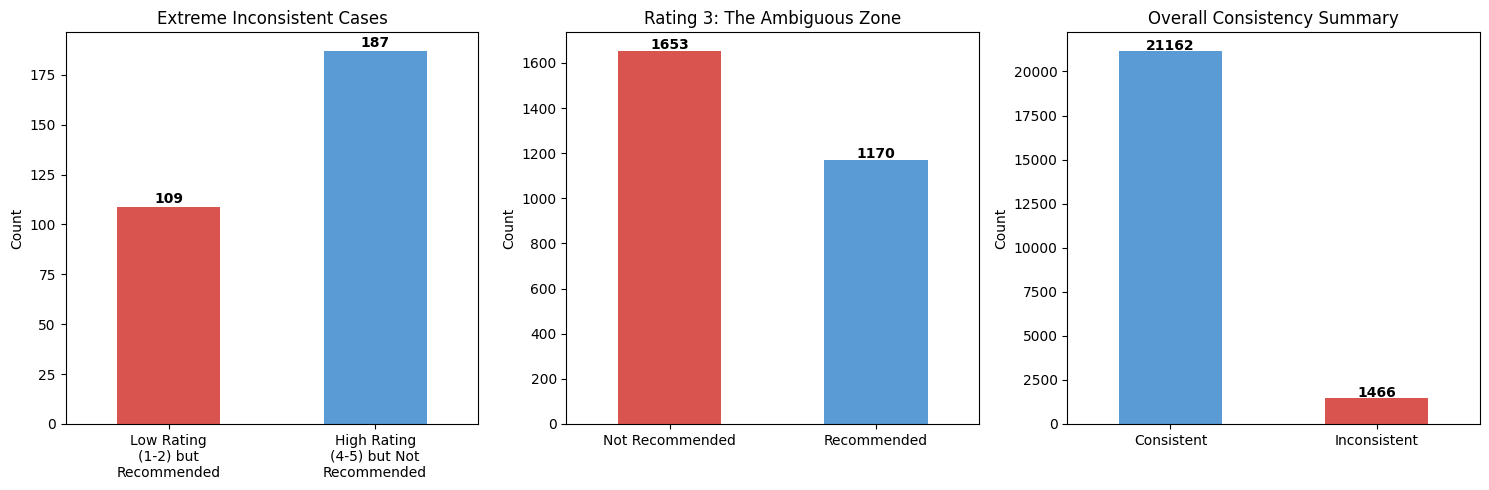

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Extreme inconsistent cases
inconsistent_counts = pd.Series({
    "Low Rating\n(1-2) but\nRecommended": 109,
    "High Rating\n(4-5) but Not\nRecommended": 187
})
inconsistent_counts.plot(kind="bar", ax=axes[0], color=["#d9534f", "#5b9bd5"])
axes[0].set_title("Extreme Inconsistent Cases")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(inconsistent_counts):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

# Plot 2: Rating 3 breakdown
rating3_counts = pd.Series({"Not Recommended": 1653, "Recommended": 1170})
rating3_counts.plot(kind="bar", ax=axes[1], color=["#d9534f", "#5b9bd5"])
axes[1].set_title("Rating 3: The Ambiguous Zone")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(rating3_counts):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Plot 3: Overall inconsistency summary
total = len(ec_df)
inconsistent_total = 109 + 187 + 1170
consistent_total = total - inconsistent_total
summary = pd.Series({"Consistent": consistent_total, "Inconsistent": inconsistent_total})
summary.plot(kind="bar", ax=axes[2], color=["#5b9bd5", "#d9534f"])
axes[2].set_title("Overall Consistency Summary")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)
for i, v in enumerate(summary):
    axes[2].text(i, v + 50, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("inconsistency_analysis.png", dpi=150)
plt.show()

In [10]:
# Read and parse LIWC dictionary file
with open("/Users/kiwi/Desktop/DD/LIWC2015 Dictionary.dic", "r", encoding="utf-8") as f:
    content = f.read()

# Split into header and word sections
parts = content.split("%")
header = parts[1].strip()
words = parts[2].strip()

# Parse categories
categories = {}
for line in header.split("\n"):
    line = line.strip()
    if line:
        num, name = line.split("\t")
        categories[num.strip()] = name.strip()

print("=== Available Categories ===")
for num, name in categories.items():
    print(f"{num}: {name}")

=== Available Categories ===
1: function
2: pronoun
3: ppron
4: i
5: we
6: you
7: shehe
8: they
9: ipron
10: article
11: prep
12: auxverb
13: adverb
14: conj
15: negate
20: verb
21: adj
22: compare
23: interrog
24: number
25: quant
30: affect
31: posemo
32: negemo
33: anx
34: anger
35: sad
40: social
41: family
42: friend
43: female
44: male
50: cogproc
51: insight
52: cause
53: discrep
54: tentat
55: certain
56: differ
60: percept
61: see
62: hear
63: feel
70: bio
71: body
72: health
73: sexual
74: ingest
80: drives
81: affiliation
82: achiev
83: power
84: reward
85: risk
90: focuspast
91: focuspresent
92: focusfuture
100: relativ
101: motion
102: space
103: time
110: work
111: leisure
112: home
113: money
114: relig
115: death
120: informal
121: swear
122: netspeak
123: assent
124: nonflu
125: filler


In [11]:
# Parse LIWC dictionary words section
liwc_categories = {"discrep": [], "tentat": []}

for line in words.split("\n"):
    line = line.strip()
    if not line:
        continue
    parts = line.split("\t")
    word = parts[0].strip()
    cats = parts[1:]
    
    if "53" in cats:
        liwc_categories["discrep"].append(word)
    if "54" in cats:
        liwc_categories["tentat"].append(word)

print(f"Discrepancy words: {len(liwc_categories['discrep'])}")
print(liwc_categories["discrep"][:20])

print(f"\nTentativeness words: {len(liwc_categories['tentat'])}")
print(liwc_categories["tentat"][:20])

Discrepancy words: 83
['abnormal*', 'besides', 'could', "could've", "couldn't", 'couldnt', 'couldve', 'desir*', 'expect*', 'hope', 'hoped', 'hopeful', 'hopefully', 'hopes', 'hoping', 'ideal*', 'if', 'impossible', 'inadequa*', 'lack']

Tentativeness words: 178
['allot', 'almost', 'alot', 'ambigu*', 'any', 'anybod*', 'anyhow', 'anyone*', 'anything', 'anytime', 'anywhere', 'apparently', 'appear', 'appeared', 'appearing', 'appears', 'apprehens*', 'approximat*', 'arbitrar*', 'assum*']


GROUP SIZES
  Group A (Rating 1-3, Recommended):     n=1279
  Group B (Rating 4-5, Recommended):     n=17248
  Group C (Rating 1-3, Not Recommended): n=3914

AVERAGE REVIEW LENGTH (words)
  Group A: 65.4
  Group B: 59.4
  Group C: 61.8

NORMALIZED SCORES (per 100 words)
  Group A — discrep: 2.1205 | tentat: 2.5479 | sj_norm: 4.6684
  Group B — discrep: 1.2978 | tentat: 2.1521 | sj_norm: 3.4499
  Group C — discrep: 1.9993 | tentat: 2.1890 | sj_norm: 4.1883

T-TESTS (normalized sj score)
  A vs B: T=13.4197, p=7.1971e-41  ***
  A vs C: T=4.4496, p=8.7827e-06  ***
  B vs C: T=-13.2424, p=7.1991e-40  ***


/var/folders/31/5msjx1xn4kl4cg9f9qqcxq840000gn/T/ipykernel_28606/1488291258.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


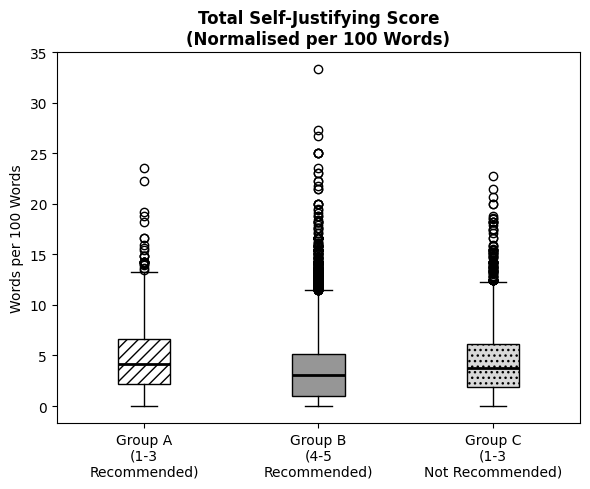

In [16]:
# ── Normalized Self-Justifying Language Analysis (Three Groups) ───────────────

# Word count function
def count_liwc_words(text, word_list):
    text = str(text).lower()
    count = 0
    for word in word_list:
        if word.endswith("*"):
            stem = word[:-1]
            count += sum(1 for w in text.split() if w.startswith(stem))
        else:
            count += sum(1 for w in text.split() if w == word)
    return count

# Compute raw counts, review length, and normalized scores
ec_df["discrep_count"] = ec_df["Review Text"].apply(
    lambda x: count_liwc_words(x, liwc_categories["discrep"]))
ec_df["tentat_count"] = ec_df["Review Text"].apply(
    lambda x: count_liwc_words(x, liwc_categories["tentat"]))
ec_df["review_length"] = ec_df["Review Text"].apply(
    lambda x: len(str(x).split()))
ec_df["discrep_norm"] = ec_df["discrep_count"] / ec_df["review_length"] * 100
ec_df["tentat_norm"]  = ec_df["tentat_count"]  / ec_df["review_length"] * 100
ec_df["sj_norm"]      = ec_df["discrep_norm"]  + ec_df["tentat_norm"]

# Define three groups
group_a = ec_df[(ec_df["Rating"] <= 3) & (ec_df["Recommended IND"] == 1)]
group_b = ec_df[(ec_df["Rating"] >= 4) & (ec_df["Recommended IND"] == 1)]
group_c = ec_df[(ec_df["Rating"] <= 3) & (ec_df["Recommended IND"] == 0)]

# Summary statistics
print("=" * 55)
print("GROUP SIZES")
print(f"  Group A (Rating 1-3, Recommended):     n={len(group_a)}")
print(f"  Group B (Rating 4-5, Recommended):     n={len(group_b)}")
print(f"  Group C (Rating 1-3, Not Recommended): n={len(group_c)}")

print("\n" + "=" * 55)
print("AVERAGE REVIEW LENGTH (words)")
print(f"  Group A: {group_a['review_length'].mean():.1f}")
print(f"  Group B: {group_b['review_length'].mean():.1f}")
print(f"  Group C: {group_c['review_length'].mean():.1f}")

print("\n" + "=" * 55)
print("NORMALIZED SCORES (per 100 words)")
for label, grp in [("Group A", group_a), ("Group B", group_b), ("Group C", group_c)]:
    print(f"  {label} — discrep: {grp['discrep_norm'].mean():.4f} | "
          f"tentat: {grp['tentat_norm'].mean():.4f} | "
          f"sj_norm: {grp['sj_norm'].mean():.4f}")

print("\n" + "=" * 55)
print("T-TESTS (normalized sj score)")
from scipy import stats
pairs = [("A vs B", group_a, group_b), ("A vs C", group_a, group_c), ("B vs C", group_b, group_c)]
for name, g1, g2 in pairs:
    t, p = stats.ttest_ind(g1["sj_norm"], g2["sj_norm"])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"  {name}: T={t:.4f}, p={p:.4e}  {sig}")

# Visualize - Total Self-Justifying Score only
labels = [
    "Group A\n(1-3\nRecommended)",
    "Group B\n(4-5\nRecommended)",
    "Group C\n(1-3\nNot Recommended)"
]

fig, ax = plt.subplots(figsize=(6, 5))

fills = ["#ffffff", "#969696", "#d9d9d9"]
hatches = ["///", "", "..."]

bp = ax.boxplot(
    [group_a["sj_norm"], group_b["sj_norm"], group_c["sj_norm"]],
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)
for patch, fill, hatch in zip(bp["boxes"], fills, hatches):
    patch.set_facecolor(fill)
    patch.set_hatch(hatch)

ax.set_title("Total Self-Justifying Score\n(Normalised per 100 Words)", fontweight="bold")
ax.set_ylabel("Words per 100 Words")

plt.tight_layout()
plt.savefig("h2_total_bw.png", dpi=300)
plt.show()

VADER SCORES (mean)
  Group A (1-3, Recommended) — pos: 0.1666 | neg: 0.0463 | neu: 0.7871 | compound: 0.6157
  Group B (4-5, Recommended) — pos: 0.2446 | neg: 0.0226 | neu: 0.7329 | compound: 0.8308
  Group C (1-3, Not Recommended) — pos: 0.1376 | neg: 0.0697 | neu: 0.7927 | compound: 0.3929

T-TESTS: A vs C
  vader_pos: T=11.2797, p=3.6025e-29  ***
  vader_neg: T=-12.4374, p=5.1423e-35  ***
  vader_compound: T=13.5577, p=3.5586e-41  ***


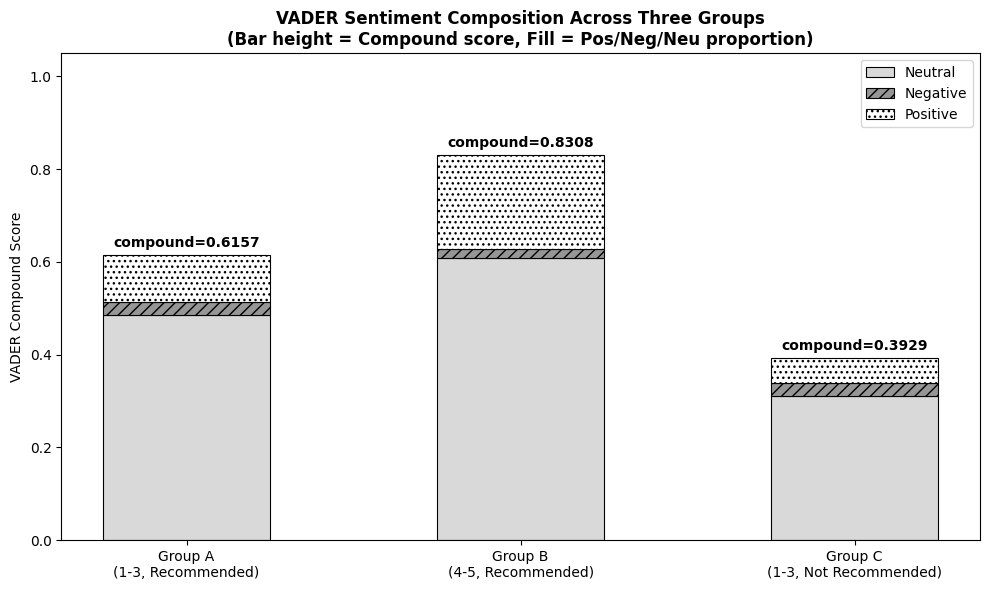

In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import numpy as np

analyzer = SentimentIntensityAnalyzer()

# Compute VADER sub-scores
ec_df["vader_pos"] = ec_df["Review Text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["pos"])
ec_df["vader_neg"] = ec_df["Review Text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["neg"])
ec_df["vader_neu"] = ec_df["Review Text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["neu"])
ec_df["vader_compound"] = ec_df["Review Text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"])

# Re-define groups
group_a = ec_df[(ec_df["Rating"] <= 3) & (ec_df["Recommended IND"] == 1)]
group_b = ec_df[(ec_df["Rating"] >= 4) & (ec_df["Recommended IND"] == 1)]
group_c = ec_df[(ec_df["Rating"] <= 3) & (ec_df["Recommended IND"] == 0)]
groups  = [group_a, group_b, group_c]

labels         = ["Group A\n(1-3, Recommended)",
                  "Group B\n(4-5, Recommended)",
                  "Group C\n(1-3, Not Recommended)"]
pos_means      = [g["vader_pos"].mean()      for g in groups]
neg_means      = [g["vader_neg"].mean()      for g in groups]
neu_means      = [g["vader_neu"].mean()      for g in groups]
compound_means = [g["vader_compound"].mean() for g in groups]

# Scale pos/neg/neu proportionally so they sum to compound value
scaled_pos = [c * p / (p + n + ne) for c, p, n, ne in zip(compound_means, pos_means, neg_means, neu_means)]
scaled_neg = [c * n / (p + n + ne) for c, p, n, ne in zip(compound_means, pos_means, neg_means, neu_means)]
scaled_neu = [c * ne / (p + n + ne) for c, p, n, ne in zip(compound_means, pos_means, neg_means, neu_means)]

# Print summary
print("=" * 55)
print("VADER SCORES (mean)")
for label, grp in zip(labels, groups):
    print(f"  {label.replace(chr(10), ' ')} — "
          f"pos: {grp['vader_pos'].mean():.4f} | "
          f"neg: {grp['vader_neg'].mean():.4f} | "
          f"neu: {grp['vader_neu'].mean():.4f} | "
          f"compound: {grp['vader_compound'].mean():.4f}")

print("\n" + "=" * 55)
print("T-TESTS: A vs C")
for col in ["vader_pos", "vader_neg", "vader_compound"]:
    t, p = stats.ttest_ind(group_a[col], group_c[col])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"  {col}: T={t:.4f}, p={p:.4e}  {sig}")

# Chart: bar height = compound, internal stacked = pos/neg/neu proportion
x     = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(10, 6))

# Greyscale fills + hatching for three sentiment layers
bar_neu = ax.bar(x, scaled_neu, width,
                  label="Neutral", color="#d9d9d9", edgecolor="black", linewidth=0.8)
bar_neg = ax.bar(x, scaled_neg, width, bottom=scaled_neu,
                  label="Negative", color="#969696", edgecolor="black", linewidth=0.8)
bar_pos = ax.bar(x, scaled_pos, width,
                  bottom=[ne + n for ne, n in zip(scaled_neu, scaled_neg)],
                  label="Positive", color="#ffffff", edgecolor="black", linewidth=0.8)

# Add hatching to distinguish layers
for bar in bar_neu:
    bar.set_hatch("")
for bar in bar_neg:
    bar.set_hatch("///")
for bar in bar_pos:
    bar.set_hatch("...")

# Compound value label on top of each bar
for i, val in enumerate(compound_means):
    ax.text(i, val + 0.01, f"compound={val:.4f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("VADER Compound Score")
ax.set_title("VADER Sentiment Composition Across Three Groups\n(Bar height = Compound score, Fill = Pos/Neg/Neu proportion)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("vader_compound_stacked_bw.png", dpi=300)
plt.show()

In [14]:
from transformers import pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load ABSA model
absa_pipe = pipeline(
    "text-classification",
    model="yangheng/deberta-v3-base-absa-v1.1",
    tokenizer="yangheng/deberta-v3-base-absa-v1.1",
    use_fast=False
)

# Random sample 500 per group
sample_a = group_a.sample(500, random_state=42)
sample_b = group_b.sample(500, random_state=42)
sample_c = group_c.sample(500, random_state=42)

print("Model loaded successfully.")
print(f"  Sample A: n={len(sample_a)}")
print(f"  Sample B: n={len(sample_b)}")
print(f"  Sample C: n={len(sample_c)}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Model loaded successfully.
  Sample A: n=500
  Sample B: n=500
  Sample C: n=500


In [35]:
# Define aspect categories for fashion e-commerce
strengths_aspects = ["quality", "fit", "fabric", "material", "color", "style", 
                     "comfort", "design", "size", "length", "look", "feel",
                     "price", "value", "shipping", "packaging"]

weakness_aspects  = ["quality", "fit", "fabric", "material", "color", "style",
                     "comfort", "design", "size", "length", "look", "feel",
                     "price", "value", "shipping", "packaging"]

def analyze_absa(texts, aspects, pipe):
    """Run ABSA for each text against each aspect, return pos/neg counts."""
    pos_counts = []
    neg_counts = []
    for text in texts:
        text = str(text)[:512]  # Truncate to model max length
        pos, neg = 0, 0
        for aspect in aspects:
            try:
                result = pipe(f"{aspect} [SEP] {text}")
                label = result[0]["label"].upper()
                if label == "POSITIVE":
                    pos += 1
                elif label == "NEGATIVE":
                    neg += 1
            except:
                continue
        pos_counts.append(pos)
        neg_counts.append(neg)
    return pos_counts, neg_counts

# Run ABSA on each sample (this will take ~20-30 mins)
print("Running ABSA on Sample A...")
a_pos, a_neg = analyze_absa(sample_a["Review Text"].tolist(), strengths_aspects, absa_pipe)
print("Running ABSA on Sample B...")
b_pos, b_neg = analyze_absa(sample_b["Review Text"].tolist(), strengths_aspects, absa_pipe)
print("Running ABSA on Sample C...")
c_pos, c_neg = analyze_absa(sample_c["Review Text"].tolist(), strengths_aspects, absa_pipe)

# Store results
sample_a = sample_a.copy()
sample_b = sample_b.copy()
sample_c = sample_c.copy()
sample_a["absa_pos"] = a_pos
sample_a["absa_neg"] = a_neg
sample_b["absa_pos"] = b_pos
sample_b["absa_neg"] = b_neg
sample_c["absa_pos"] = c_pos
sample_c["absa_neg"] = c_neg

# Strength ratio = pos / (pos + neg), higher = more emphasis on strengths
sample_a["strength_ratio"] = sample_a["absa_pos"] / (sample_a["absa_pos"] + sample_a["absa_neg"]).replace(0, np.nan)
sample_b["strength_ratio"] = sample_b["absa_pos"] / (sample_b["absa_pos"] + sample_b["absa_neg"]).replace(0, np.nan)
sample_c["strength_ratio"] = sample_c["absa_pos"] / (sample_c["absa_pos"] + sample_c["absa_neg"]).replace(0, np.nan)

print("\nDone! Results summary:")
print(f"  Sample A — avg pos: {np.mean(a_pos):.2f} | avg neg: {np.mean(a_neg):.2f} | strength ratio: {sample_a['strength_ratio'].mean():.4f}")
print(f"  Sample B — avg pos: {np.mean(b_pos):.2f} | avg neg: {np.mean(b_neg):.2f} | strength ratio: {sample_b['strength_ratio'].mean():.4f}")
print(f"  Sample C — avg pos: {np.mean(c_pos):.2f} | avg neg: {np.mean(c_neg):.2f} | strength ratio: {sample_c['strength_ratio'].mean():.4f}")

Running ABSA on Sample A...
Running ABSA on Sample B...
Running ABSA on Sample C...

Done! Results summary:
  Sample A — avg pos: 8.15 | avg neg: 7.72 | strength ratio: 0.5136
  Sample B — avg pos: 15.05 | avg neg: 0.86 | strength ratio: 0.9445
  Sample C — avg pos: 3.60 | avg neg: 12.33 | strength ratio: 0.2268


In [39]:
from scipy.stats import kruskal, mannwhitneyu

# Drop NaN values before testing
a_sr = sample_a["strength_ratio"].dropna()
b_sr = sample_b["strength_ratio"].dropna()
c_sr = sample_c["strength_ratio"].dropna()

print("=" * 60)
print("H4: ABSA Strength Ratio")
stat, p = kruskal(a_sr, b_sr, c_sr)
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print(f"  Kruskal-Wallis: H={stat:.4f}, p={p:.4e}  {sig}")

for name, g1, g2 in [("A vs B", a_sr, b_sr),
                      ("A vs C", a_sr, c_sr),
                      ("B vs C", b_sr, c_sr)]:
    u, p2 = mannwhitneyu(g1, g2, alternative="two-sided")
    sig2 = "***" if p2 < 0.001 else ("**" if p2 < 0.01 else ("*" if p2 < 0.05 else "ns"))
    print(f"  Mann-Whitney U {name}: U={u:.0f}, p={p2:.4e}  {sig2}")

H4: ABSA Strength Ratio
  Kruskal-Wallis: H=653.9479, p=9.9317e-143  ***
  Mann-Whitney U A vs B: U=52344, p=1.4142e-73  ***
  Mann-Whitney U A vs C: U=171887, p=7.2712e-28  ***
  Mann-Whitney U B vs C: U=227750, p=8.2524e-134  ***


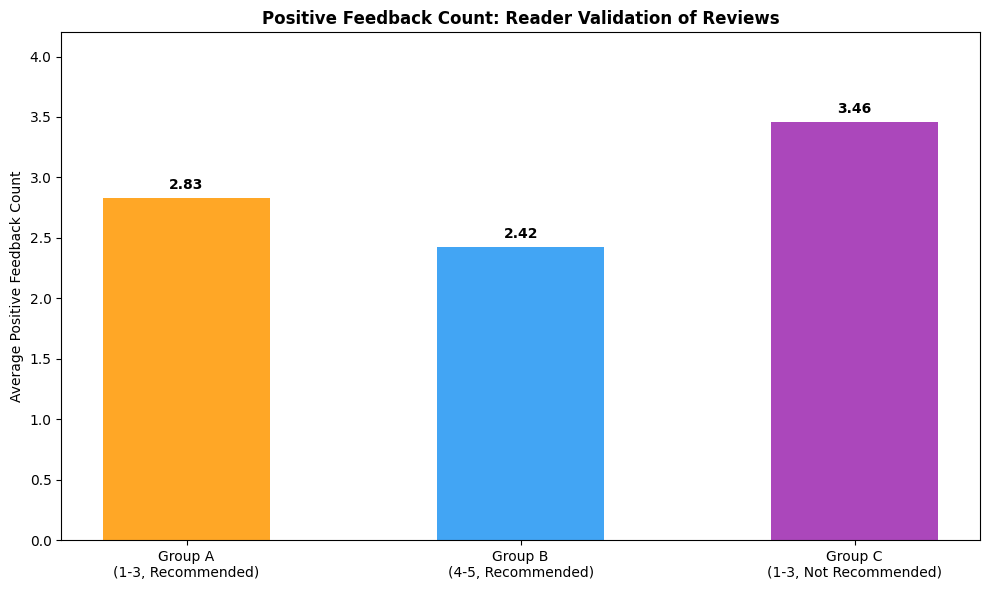

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

main_means  = [group_a["Positive Feedback Count"].mean(),
               group_b["Positive Feedback Count"].mean(),
               group_c["Positive Feedback Count"].mean()]
main_labels = ["Group A\n(1-3, Recommended)",
               "Group B\n(4-5, Recommended)",
               "Group C\n(1-3, Not Recommended)"]
colors_main = ["#FF9800", "#2196F3", "#9C27B0"]

bars = ax.bar(np.arange(3), main_means, width=0.5,
              color=colors_main, alpha=0.85)
for bar, val in zip(bars, main_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_xticks(np.arange(3))
ax.set_xticklabels(main_labels, fontsize=10)
ax.set_ylabel("Average Positive Feedback Count")
ax.set_title("Positive Feedback Count: Reader Validation of Reviews",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, 4.2)

plt.tight_layout()
plt.savefig("helpful_counts.png", dpi=150)
plt.show()

In [19]:
from scipy.stats import mannwhitneyu

print("=" * 55)
print("MANN-WHITNEY U TESTS (Positive Feedback Count)")
pairs = [("A vs B", group_a, group_b),
         ("A vs C", group_a, group_c),
         ("B vs C", group_b, group_c)]

for name, g1, g2 in pairs:
    u, p = mannwhitneyu(g1["Positive Feedback Count"],
                        g2["Positive Feedback Count"],
                        alternative="two-sided")
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"  {name}: U={u:.0f}, p={p:.4e}  {sig}")

MANN-WHITNEY U TESTS (Positive Feedback Count)
  A vs B: U=11612386, p=8.2278e-04  ***
  A vs C: U=2360298, p=1.4450e-03  **
  B vs C: U=30049576, p=8.6405e-30  ***


In [20]:
print("Division Name:", ec_df["Division Name"].value_counts().to_dict())
print("\nDepartment Name:", ec_df["Department Name"].value_counts().to_dict())
print("\nClass Name:", ec_df["Class Name"].value_counts().to_dict())

Division Name: {'General': 13365, 'General Petite': 7837, 'Initmates': 1426}

Department Name: {'Tops': 10048, 'Dresses': 6145, 'Bottoms': 3662, 'Intimate': 1653, 'Jackets': 1002, 'Trend': 118}

Class Name: {'Dresses': 6145, 'Knits': 4626, 'Blouses': 2983, 'Sweaters': 1380, 'Pants': 1350, 'Jeans': 1104, 'Fine gauge': 1059, 'Skirts': 903, 'Jackets': 683, 'Lounge': 669, 'Swim': 332, 'Outerwear': 319, 'Shorts': 304, 'Sleep': 214, 'Legwear': 158, 'Intimates': 147, 'Layering': 132, 'Trend': 118, 'Casual bottoms': 1, 'Chemises': 1}


In [21]:
# Calculate cognitive dissonance rate by Department
print("=" * 55)
print("COGNITIVE DISSONANCE RATE BY DEPARTMENT")
print("(Dissonance = Rating 1-3 + Recommended)")
print("=" * 55)

dept_stats = []
for dept in ec_df["Department Name"].dropna().unique():
    dept_df = ec_df[ec_df["Department Name"] == dept]
    total = len(dept_df)
    low_rating = dept_df[dept_df["Rating"] <= 3]
    dissonant = low_rating[low_rating["Recommended IND"] == 1]
    rate = len(dissonant) / total * 100
    dept_stats.append({
        "Department": dept,
        "Total": total,
        "Low Rating": len(low_rating),
        "Dissonant": len(dissonant),
        "Dissonance Rate (%)": round(rate, 2)
    })

dept_df_summary = pd.DataFrame(dept_stats).sort_values("Dissonance Rate (%)", ascending=False)
print(dept_df_summary.to_string(index=False))

COGNITIVE DISSONANCE RATE BY DEPARTMENT
(Dissonance = Rating 1-3 + Recommended)
Department  Total  Low Rating  Dissonant  Dissonance Rate (%)
     Trend    118          40         11                 9.32
   Dresses   6145        1511        384                 6.25
      Tops  10048        2396        560                 5.57
   Bottoms   3662         724        202                 5.52
  Intimate   1653         324         80                 4.84
   Jackets   1002         198         42                 4.19


CHI-SQUARE TEST: Dissonance Rate across Departments
  Chi2=13.3833, df=5, p=2.0040e-02  *

Note: Trend department n=118 (interpret with caution)


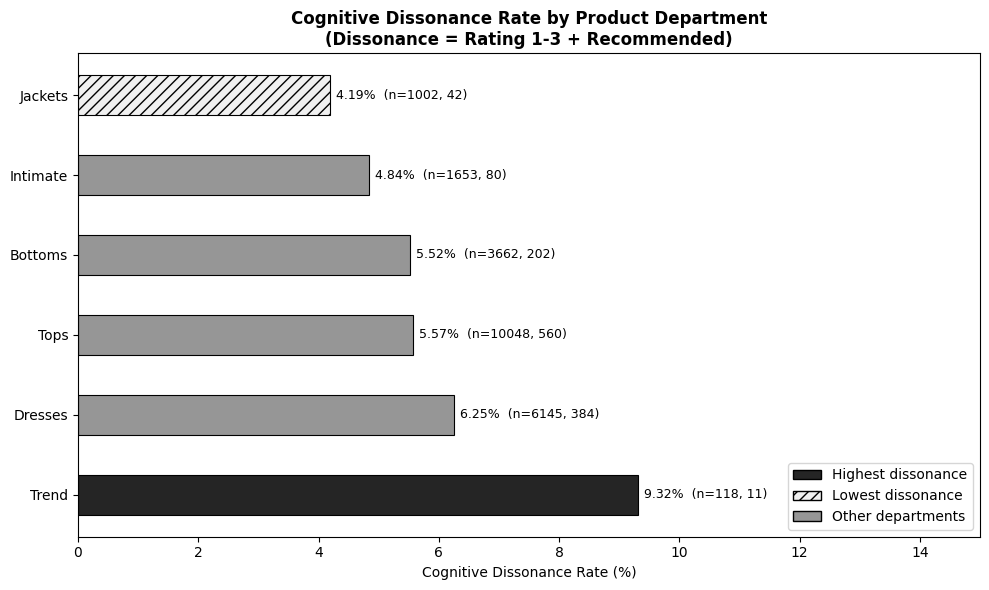

In [23]:
# Cognitive Dissonance Rate by Department with Chi-square test
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import numpy as np

# Build contingency data
departments = dept_df_summary["Department"].tolist()
dissonance_rates = dept_df_summary["Dissonance Rate (%)"].tolist()
dissonant_counts = dept_df_summary["Dissonant"].tolist()
total_counts = dept_df_summary["Total"].tolist()

# Chi-square test: is dissonance rate significantly different across departments?
contingency = [[d, t - d] for d, t in zip(dissonant_counts, total_counts)]
chi2, p, dof, expected = chi2_contingency(contingency)
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))

print("=" * 55)
print("CHI-SQUARE TEST: Dissonance Rate across Departments")
print(f"  Chi2={chi2:.4f}, df={dof}, p={p:.4e}  {sig}")
print("\nNote: Trend department n=118 (interpret with caution)")

# Visualization - Horizontal Bar Chart (B&W)
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by dissonance rate (highest to lowest)
sorted_data = sorted(zip(dissonance_rates, departments, total_counts, dissonant_counts), reverse=True)
sorted_rates, sorted_depts, sorted_totals, sorted_dissonants = zip(*sorted_data)

# Grey shades: darkest for highest, lightest for lowest
fills = []
hatches = []
for i, rate in enumerate(sorted_rates):
    if rate == max(sorted_rates):
        fills.append("#252525")
        hatches.append("")
    elif rate == min(sorted_rates):
        fills.append("#f0f0f0")
        hatches.append("///")
    else:
        fills.append("#969696")
        hatches.append("")

bars = ax.barh(sorted_depts, sorted_rates, height=0.5,
               color=fills, edgecolor="black", linewidth=0.8)

for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Value labels + sample size on the right of each bar
for bar, val, total, dissonant in zip(bars, sorted_rates, sorted_totals, sorted_dissonants):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val}%  (n={total}, {dissonant})",
            ha="left", va="center", fontsize=9)

ax.set_xlabel("Cognitive Dissonance Rate (%)")
ax.set_title("Cognitive Dissonance Rate by Product Department\n"
             "(Dissonance = Rating 1-3 + Recommended)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 15)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#252525", edgecolor="black", label="Highest dissonance"),
    Patch(facecolor="#f0f0f0", edgecolor="black", hatch="///", label="Lowest dissonance"),
    Patch(facecolor="#969696", edgecolor="black", label="Other departments")
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("dissonance_by_department_bw.png", dpi=300)
plt.show()

In [20]:
print("Age distribution:")
print(ec_df["Age"].describe())
print("\nAge value counts (top 20):")
print(ec_df["Age"].value_counts().head(20))

Age distribution:
count    22628.000000
mean        43.282880
std         12.328176
min         18.000000
25%         34.000000
50%         41.000000
75%         52.000000
max         99.000000
Name: Age, dtype: float64

Age value counts (top 20):
Age
39    1225
35     851
36     799
34     765
38     751
37     726
41     717
33     698
46     691
42     625
48     605
44     596
32     594
40     584
43     554
31     549
47     544
53     536
45     511
29     503
Name: count, dtype: int64


In [21]:
# Age group definition based on Pew Research (2019) generational framework
bins   = [0, 27, 43, 59, 100]
labels = ["Gen Z (18-27)", "Millennials (28-43)", 
          "Gen X (44-59)", "Baby Boomers (60+)"]
ec_df["Age Group"] = pd.cut(ec_df["Age"], bins=bins, labels=labels)

print(ec_df["Age Group"].value_counts().sort_index())

Age Group
Gen Z (18-27)           1928
Millennials (28-43)    10729
Gen X (44-59)           7252
Baby Boomers (60+)      2719
Name: count, dtype: int64


KRUSKAL-WALLIS TEST (Positive Feedback Count by Age Group)
  H=80.4088, p=2.5081e-17  ***

Group means:
  Gen Z (18-27): mean=2.1364 | median=0.0 | n=1928
  Millennials (28-43): mean=2.5646 | median=1.0 | n=10729
  Gen X (44-59): mean=2.7439 | median=1.0 | n=7252
  Baby Boomers (60+): mean=2.9489 | median=1.0 | n=2719

Pairwise Mann-Whitney U Tests:
  Gen Z vs Millennials: p=3.5673e-04  ***
  Gen Z vs Gen X: p=5.2853e-11  ***
  Gen Z vs Baby Boomers: p=1.5747e-13  ***
  Millennials vs Gen X: p=2.5941e-07  ***
  Millennials vs Baby Boomers: p=1.9814e-09  ***
  Gen X vs Baby Boomers: p=2.5895e-02  *


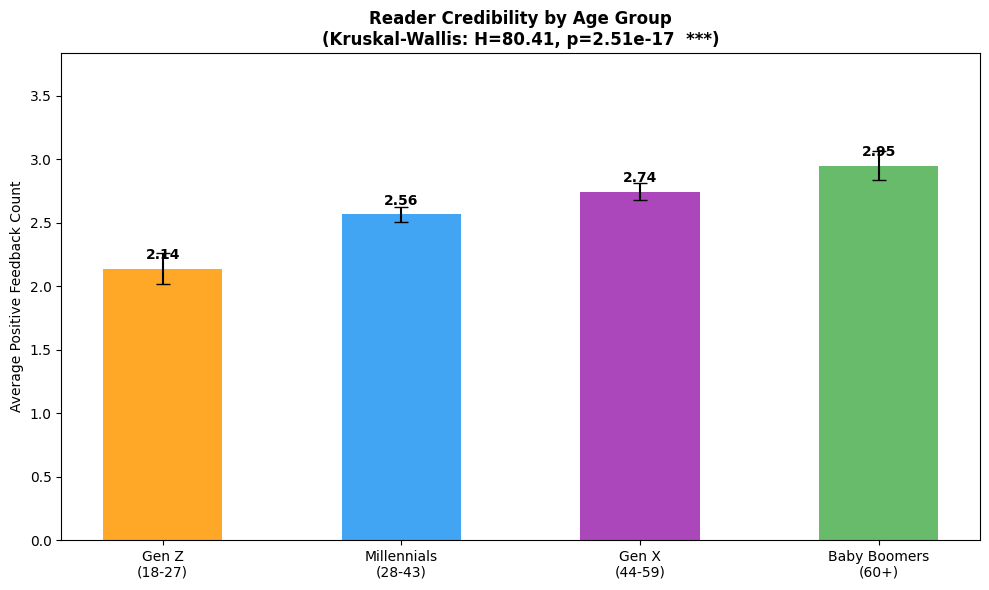

In [22]:
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import numpy as np

# ── Define age groups ─────────────────────────────────────────────────────────
bins   = [0, 27, 43, 59, 100]
labels = ["Gen Z\n(18-27)", "Millennials\n(28-43)",
          "Gen X\n(44-59)", "Baby Boomers\n(60+)"]
ec_df["Age Group"] = pd.cut(ec_df["Age"], bins=bins, labels=labels)

# ── Split helpful counts by age group ────────────────────────────────────────
groups = [ec_df[ec_df["Age Group"] == label]["Positive Feedback Count"].dropna()
          for label in labels]

# ── Kruskal-Wallis test ───────────────────────────────────────────────────────
stat, p = kruskal(*groups)
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print("=" * 55)
print("KRUSKAL-WALLIS TEST (Positive Feedback Count by Age Group)")
print(f"  H={stat:.4f}, p={p:.4e}  {sig}")
print("\nGroup means:")
for label, group in zip(labels, groups):
    print(f"  {label.replace(chr(10), ' ')}: mean={group.mean():.4f} | median={group.median():.1f} | n={len(group)}")

# ── Post-hoc: Mann-Whitney U pairwise ─────────────────────────────────────────
from scipy.stats import mannwhitneyu
from itertools import combinations

print("\nPairwise Mann-Whitney U Tests:")
label_list = ["Gen Z", "Millennials", "Gen X", "Baby Boomers"]
for (i, g1), (j, g2) in combinations(enumerate(groups), 2):
    u, p_pair = mannwhitneyu(g1, g2, alternative="two-sided")
    sig_pair  = "***" if p_pair < 0.001 else ("**" if p_pair < 0.01 else ("*" if p_pair < 0.05 else "ns"))
    print(f"  {label_list[i]} vs {label_list[j]}: p={p_pair:.4e}  {sig_pair}")

# ── Visualization ─────────────────────────────────────────────────────────────
means   = [g.mean() for g in groups]
sems    = [g.sem()  for g in groups]
colors  = ["#FF9800", "#2196F3", "#9C27B0", "#4CAF50"]
x       = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, means, width=0.5, color=colors, alpha=0.85,
              yerr=sems, capsize=5, error_kw=dict(elinewidth=1.5))

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Average Positive Feedback Count")
ax.set_title("Reader Credibility by Age Group\n"
             f"(Kruskal-Wallis: H={stat:.2f}, p={p:.2e}  {sig})",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, max(means) * 1.3)

plt.tight_layout()
plt.savefig("helpful_by_age.png", dpi=150)
plt.show()

In [23]:
for label in ["Gen Z\n(18-27)", "Millennials\n(28-43)", 
              "Gen X\n(44-59)", "Baby Boomers\n(60+)"]:
    group = ec_df[ec_df["Age Group"] == label]
    avg_len = group["Review Text"].apply(lambda x: len(str(x).split())).mean()
    print(f"{label.replace(chr(10), ' ')}: avg length = {avg_len:.1f} words")

Gen Z (18-27): avg length = 59.7 words
Millennials (28-43): avg length = 60.3 words
Gen X (44-59): avg length = 59.6 words
Baby Boomers (60+): avg length = 62.0 words


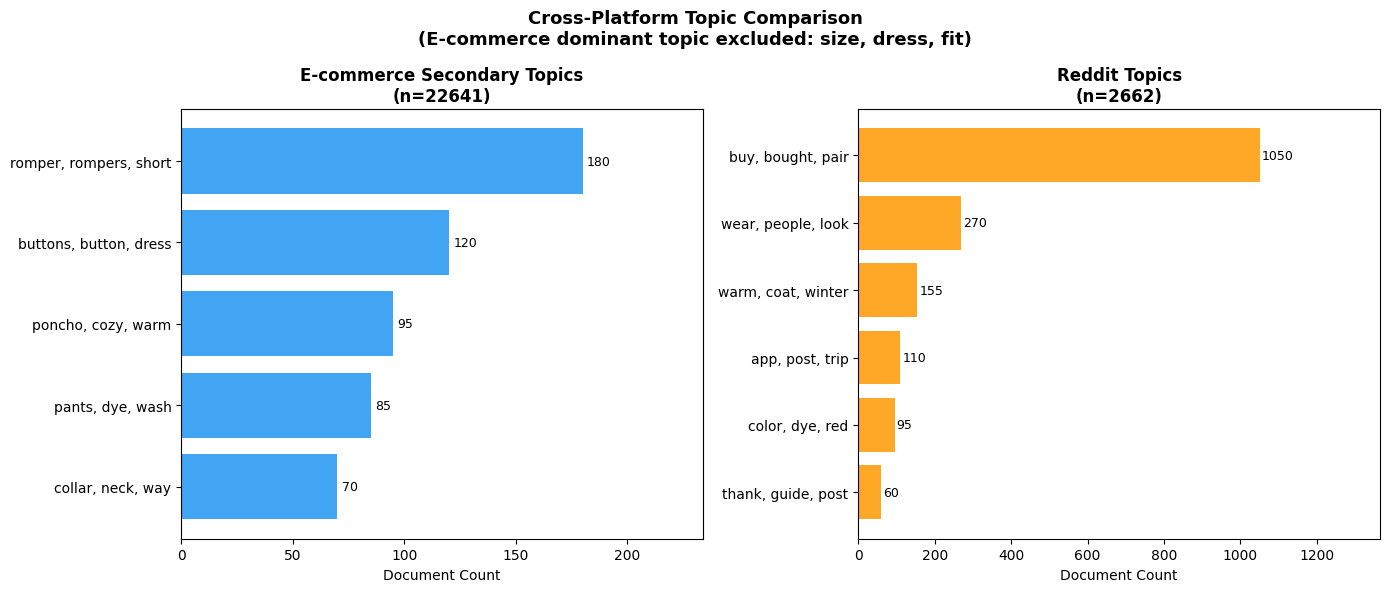

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ── Topic data (excluding dominant Topic 0 from E-commerce) ──────────────────
ec_topics = {
    "romper, rompers, short": 180,
    "buttons, button, dress": 120,
    "poncho, cozy, warm":      95,
    "pants, dye, wash":        85,
    "collar, neck, way":       70,
}

reddit_topics = {
    "buy, bought, pair":   1050,
    "wear, people, look":   270,
    "warm, coat, winter":   155,
    "app, post, trip":      110,
    "color, dye, red":       95,
    "thank, guide, post":    60,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Cross-Platform Topic Comparison\n"
             "(E-commerce dominant topic excluded: size, dress, fit)",
             fontsize=13, fontweight="bold")

# Left: E-commerce
labels_ec = list(ec_topics.keys())
values_ec = list(ec_topics.values())
axes[0].barh(labels_ec[::-1], values_ec[::-1], color="#2196F3", alpha=0.85)
for i, (label, val) in enumerate(zip(labels_ec[::-1], values_ec[::-1])):
    axes[0].text(val + 2, i, str(val), va="center", fontsize=9)
axes[0].set_title("E-commerce Secondary Topics\n(n=22641)", fontweight="bold")
axes[0].set_xlabel("Document Count")
axes[0].set_xlim(0, max(values_ec) * 1.3)

# Right: Reddit
labels_rd = list(reddit_topics.keys())
values_rd = list(reddit_topics.values())
axes[1].barh(labels_rd[::-1], values_rd[::-1], color="#FF9800", alpha=0.85)
for i, (label, val) in enumerate(zip(labels_rd[::-1], values_rd[::-1])):
    axes[1].text(val + 5, i, str(val), va="center", fontsize=9)
axes[1].set_title("Reddit Topics\n(n=2662)", fontweight="bold")
axes[1].set_xlabel("Document Count")
axes[1].set_xlim(0, max(values_rd) * 1.3)

plt.tight_layout()
plt.savefig("topic_comparison_clean.png", dpi=150)
plt.show()

MANN-WHITNEY U TESTS: E-commerce vs Reddit
  vader_compound: U=39610346, p=2.2388e-156  ***
  vader_pos: U=41397286, p=6.0447e-220  ***
  vader_neg: U=24779028, p=1.5723e-55  ***
  vader_neu: U=21756616, p=8.9036e-122  ***


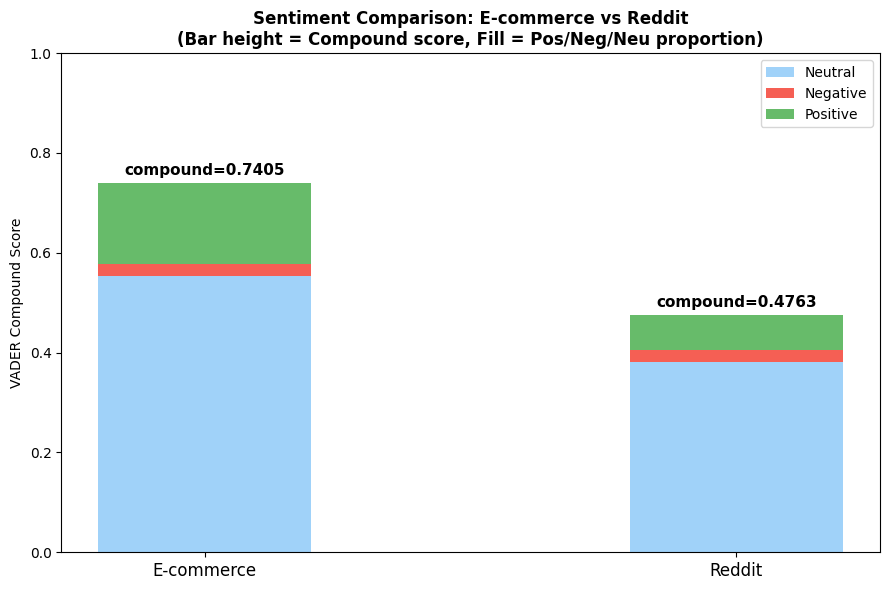

In [24]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

analyzer = SentimentIntensityAnalyzer()

# ── Load Reddit data ──────────────────────────────────────────────────────────
reddit_df = pd.read_csv("/Users/kiwi/Desktop/DD/reddit_comments.csv")

# ── Compute VADER scores ──────────────────────────────────────────────────────
reddit_df["vader_compound"] = reddit_df["comment"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"])
reddit_df["vader_pos"] = reddit_df["comment"].apply(
    lambda x: analyzer.polarity_scores(str(x))["pos"])
reddit_df["vader_neg"] = reddit_df["comment"].apply(
    lambda x: analyzer.polarity_scores(str(x))["neg"])
reddit_df["vader_neu"] = reddit_df["comment"].apply(
    lambda x: analyzer.polarity_scores(str(x))["neu"])

# ── E-commerce overall scores (all reviews) ───────────────────────────────────
ec_compound = ec_df["vader_compound"].mean()
ec_pos      = ec_df["vader_pos"].mean()
ec_neg      = ec_df["vader_neg"].mean()
ec_neu      = ec_df["vader_neu"].mean()

rd_compound = reddit_df["vader_compound"].mean()
rd_pos      = reddit_df["vader_pos"].mean()
rd_neg      = reddit_df["vader_neg"].mean()
rd_neu      = reddit_df["vader_neu"].mean()

# ── U-test ────────────────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu

print("MANN-WHITNEY U TESTS: E-commerce vs Reddit")
for col in ["vader_compound", "vader_pos", "vader_neg", "vader_neu"]:
    u, p = mannwhitneyu(ec_df[col], reddit_df[col], alternative="two-sided")
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"  {col}: U={u:.0f}, p={p:.4e}  {sig}")

# ── Visualization: stacked bar ────────────────────────────────────────────────
platforms      = ["E-commerce", "Reddit"]
pos_means      = [ec_pos,      rd_pos]
neg_means      = [ec_neg,      rd_neg]
neu_means      = [ec_neu,      rd_neu]
compound_means = [ec_compound, rd_compound]

scaled_pos = [c * p / (p + n + ne) for c, p, n, ne in
              zip(compound_means, pos_means, neg_means, neu_means)]
scaled_neg = [c * n / (p + n + ne) for c, p, n, ne in
              zip(compound_means, pos_means, neg_means, neu_means)]
scaled_neu = [c * ne / (p + n + ne) for c, p, n, ne in
              zip(compound_means, pos_means, neg_means, neu_means)]

x     = np.arange(2)
width = 0.4

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x, scaled_neu, width, label="Neutral",  color="#90CAF9", alpha=0.85)
ax.bar(x, scaled_neg, width, bottom=scaled_neu, label="Negative", color="#F44336", alpha=0.85)
ax.bar(x, scaled_pos, width,
       bottom=[ne + n for ne, n in zip(scaled_neu, scaled_neg)],
       label="Positive", color="#4CAF50", alpha=0.85)

for i, val in enumerate(compound_means):
    ax.text(i, val + 0.01, f"compound={val:.4f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(platforms, fontsize=12)
ax.set_ylabel("VADER Compound Score")
ax.set_title("Sentiment Comparison: E-commerce vs Reddit\n"
             "(Bar height = Compound score, Fill = Pos/Neg/Neu proportion)",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig("vader_cross_platform.png", dpi=150)
plt.show()

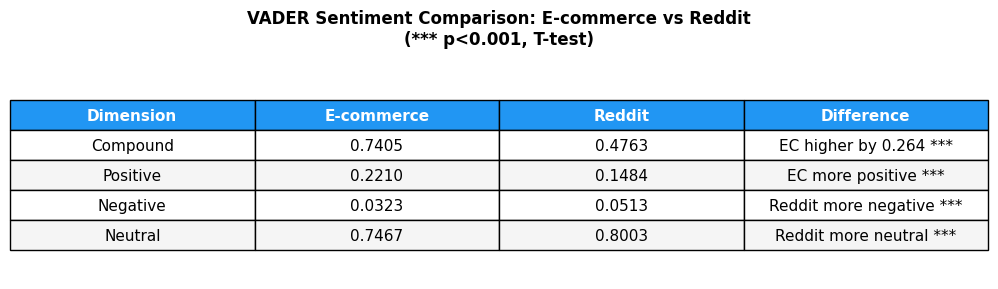

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

columns = ["Dimension", "E-commerce", "Reddit", "Difference"]
rows = [
    ["Compound", "0.7405", "0.4763", "EC higher by 0.264 ***"],
    ["Positive",  "0.2210", "0.1484", "EC more positive ***"],
    ["Negative",  "0.0323", "0.0513", "Reddit more negative ***"],
    ["Neutral",   "0.7467", "0.8003", "Reddit more neutral ***"],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# Style header
for j in range(len(columns)):
    table[0, j].set_facecolor("#2196F3")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Style rows
for i in range(1, len(rows)+1):
    for j in range(len(columns)):
        table[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")

ax.set_title("VADER Sentiment Comparison: E-commerce vs Reddit\n"
             "(*** p<0.001, T-test)",
             fontsize=12, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("vader_table.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
!pip3 install tabulate


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [28]:
import pandas as pd

im_table = pd.DataFrame({
    "Dimension": ["Topic Strategy", "Sentiment Strategy", "IM Intensity"],
    "E-commerce": [
        "Product Expertise Presentation",
        "Positive amplification (compound=0.74)",
        "Strong"
    ],
    "Reddit": [
        "Lifestyle Identity Presentation",
        "Authentic expression (compound=0.48)",
        "Moderate"
    ]
})

print(im_table.to_markdown(index=False))

| Dimension          | E-commerce                             | Reddit                               |
|:-------------------|:---------------------------------------|:-------------------------------------|
| Topic Strategy     | Product Expertise Presentation         | Lifestyle Identity Presentation      |
| Sentiment Strategy | Positive amplification (compound=0.74) | Authentic expression (compound=0.48) |
| IM Intensity       | Strong                                 | Moderate                             |


In [29]:
from scipy.stats import kruskal, mannwhitneyu

print("=" * 60)
print("NON-PARAMETRIC TESTS")
print("=" * 60)

# H2: Self-justifying language
print("\nH2: Self-Justifying Language (sj_norm)")
stat, p = kruskal(group_a["sj_norm"], group_b["sj_norm"], group_c["sj_norm"])
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print(f"  Kruskal-Wallis: H={stat:.4f}, p={p:.4e}  {sig}")
for name, g1, g2 in [("A vs B", group_a["sj_norm"], group_b["sj_norm"]),
                      ("A vs C", group_a["sj_norm"], group_c["sj_norm"]),
                      ("B vs C", group_b["sj_norm"], group_c["sj_norm"])]:
    u, p2 = mannwhitneyu(g1, g2, alternative="two-sided")
    sig2 = "***" if p2 < 0.001 else ("**" if p2 < 0.01 else ("*" if p2 < 0.05 else "ns"))
    print(f"  Mann-Whitney U {name}: U={u:.0f}, p={p2:.4e}  {sig2}")

# H3: VADER compound
print("\nH3: VADER Compound Sentiment")
stat, p = kruskal(group_a["vader_compound"], group_b["vader_compound"], group_c["vader_compound"])
sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
print(f"  Kruskal-Wallis: H={stat:.4f}, p={p:.4e}  {sig}")
for name, g1, g2 in [("A vs B", group_a["vader_compound"], group_b["vader_compound"]),
                      ("A vs C", group_a["vader_compound"], group_c["vader_compound"]),
                      ("B vs C", group_b["vader_compound"], group_c["vader_compound"])]:
    u, p2 = mannwhitneyu(g1, g2, alternative="two-sided")
    sig2 = "***" if p2 < 0.001 else ("**" if p2 < 0.01 else ("*" if p2 < 0.05 else "ns"))
    print(f"  Mann-Whitney U {name}: U={u:.0f}, p={p2:.4e}  {sig2}")

NON-PARAMETRIC TESTS

H2: Self-Justifying Language (sj_norm)
  Kruskal-Wallis: H=314.4801, p=5.1465e-69  ***
  Mann-Whitney U A vs B: U=13440254, p=1.7645e-39  ***
  Mann-Whitney U A vs C: U=2715377, p=4.8146e-06  ***
  Mann-Whitney U B vs C: U=29187044, p=1.7797e-40  ***

H3: VADER Compound Sentiment
  Kruskal-Wallis: H=3867.9706, p=0.0000e+00  ***
  Mann-Whitney U A vs B: U=6558500, p=1.1027e-129  ***
  Mann-Whitney U A vs C: U=3162968, p=1.2536e-45  ***
  Mann-Whitney U B vs C: U=54285232, p=0.0000e+00  ***
